# Data Exploration

Initial exploration of simulation data using the `reconn_wave_power` module.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from reconn_wave_power.io import read_simulation
from reconn_wave_power.spectrum import compute_psd_time, compute_psd_space, compute_komega_2d
from reconn_wave_power.plotting import plot_psd

%matplotlib inline

## Configuration

Set paths to your simulation data here.

In [2]:
# Path to simulation input file and output folder
INPUT_FILE = "/Users/colby/Research/Projects/My_Projects/2026.Reconn_Wave_Power/test_sim_data/test00/input/input"
OUTPUT_FOLDER = "/Users/colby/Research/Projects/My_Projects/2026.Reconn_Wave_Power/test_sim_data/test00/Output"

## Load Simulation Data

In [3]:
# Load E and B fields for all timesteps
ds = read_simulation(
    input_file=INPUT_FILE,
    output_folder=OUTPUT_FOLDER,
    fields=("E", "B"),
    progress=True,
)
ds

Loading timesteps:   0%|          | 0/1001 [00:00<?, ?ts/s]

<xarray.Dataset> Size: 15GB
Dimensions:  (time: 1001, x: 1600, y: 400)
Coordinates:
  * time     (time) float64 8kB 0.05 2.0 4.0 6.0 ... 1.996e+03 1.998e+03 2e+03
  * x        (x) float64 13kB 0.25 0.75 1.25 1.75 ... 798.2 798.8 799.2 799.8
  * y        (y) float64 3kB 0.25 0.75 1.25 1.75 ... 198.2 198.8 199.2 199.8
Data variables:
    Ex       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Ey       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Ez       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Bx       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    By       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Bz       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
Attributes:
    dt:       0.05

In [4]:
# Check what we loaded
print("Variables:", list(ds.data_vars))
print("Dimensions:", dict(ds.sizes))
print("Attributes:", ds.attrs)

Variables: ['Ex', 'Ey', 'Ez', 'Bx', 'By', 'Bz']
Dimensions: {'time': 1001, 'x': 1600, 'y': 400}
Attributes: {'dt': 0.05}


## Quick Look at the Data

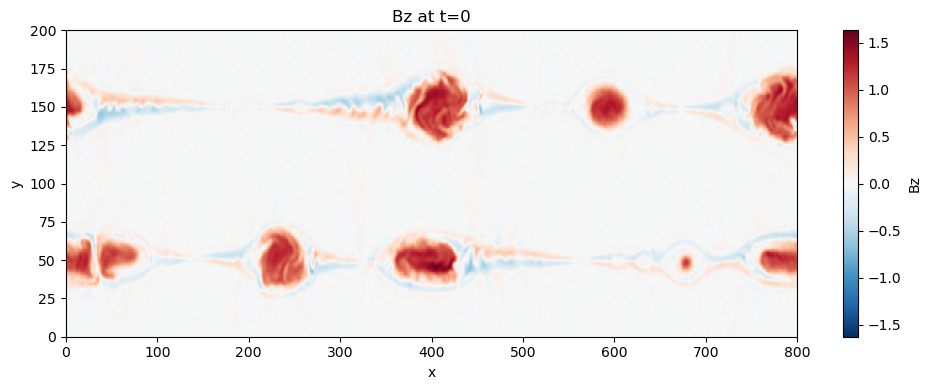

In [5]:
# Plot a single component at a single timestep
fig, ax = plt.subplots(figsize=(10, 4))
ds["Bz"].isel(time=200).plot(ax=ax, x="x", y="y")
plt.title("Bz at t=0")
plt.tight_layout()

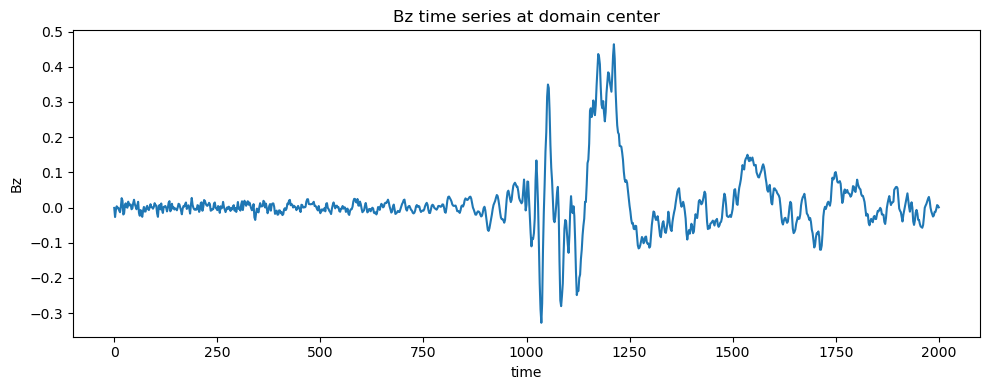

In [6]:
# Time series at a specific location
# Adjust x, y indices based on your data dimensions
fig, ax = plt.subplots(figsize=(10, 4))
ds["Bz"].isel(x=ds.sizes["x"]//2, y=ds.sizes["y"]//2).plot(ax=ax)
plt.title("Bz time series at domain center")
plt.tight_layout()

## Time-Domain Power Spectrum

In [7]:
# Extract a time series at a single spatial point
bz_ts = ds["Bz"].isel(x=ds.sizes["x"]//2, y=ds.sizes["y"]//2)
dt = ds.attrs.get("dt", 1.0)  # fallback to 1.0 if not set

print(f"Time series length: {len(bz_ts.time)} points")
print(f"dt = {dt}")

Time series length: 1001 points
dt = 0.05


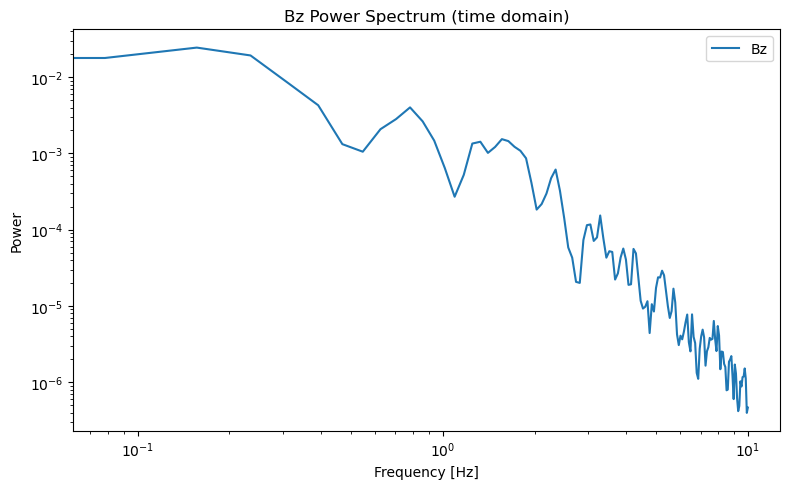

In [8]:
# Compute PSD
f, Pxx = compute_psd_time(bz_ts, dt=dt)

fig, ax = plt.subplots(figsize=(8, 5))
plot_psd(f, Pxx, label="Bz", ax=ax)
plt.title("Bz Power Spectrum (time domain)")
plt.tight_layout()

## Spatial Power Spectrum

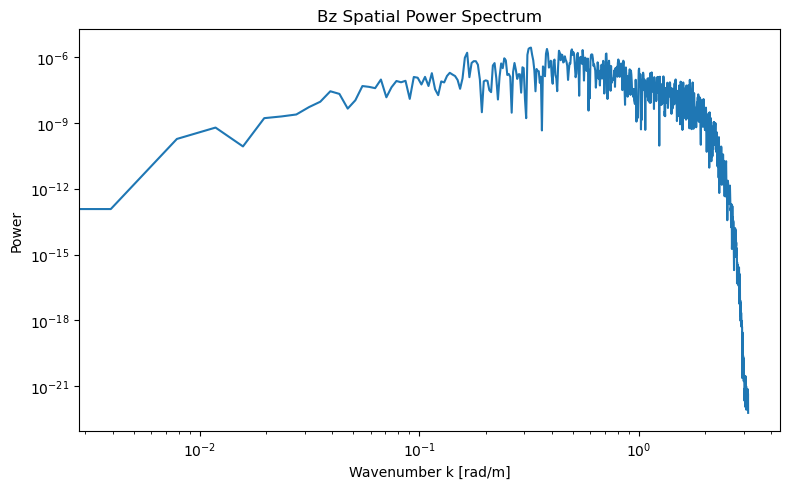

In [9]:
# Compute spatial PSD along x at a single timestep
bz_spatial = ds["Bz"].isel(time=0, y=ds.sizes["y"]//2)
dx = ds.attrs.get("dx", 1.0)

k, Pk = compute_psd_space(bz_spatial, dx=dx, axis="x")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k, Pk)
ax.set_xlabel("Wavenumber k [rad/m]")
ax.set_ylabel("Power")
ax.set_title("Bz Spatial Power Spectrum")
plt.tight_layout()

## k-omega Spectrum (2D)

In [10]:
# Extract a 2D slice (x, time) at fixed y
bz_xt = ds["Bz"].isel(y=ds.sizes["y"]//2).values  # shape: (time, x)

# compute_komega_2d expects (space, time) or specify axes
# Our data is (time, x), so axes=(1, 0) means space=axis1, time=axis0
k, omega, P = compute_komega_2d(bz_xt, dx=dx, dt=dt, axes=(1, 0))

print(f"k range: {k.min():.3f} to {k.max():.3f} rad/m")
print(f"omega range: {omega.min():.3f} to {omega.max():.3f} rad/s")

k range: -3.142 to 3.138 rad/m
omega range: -62.769 to 62.769 rad/s


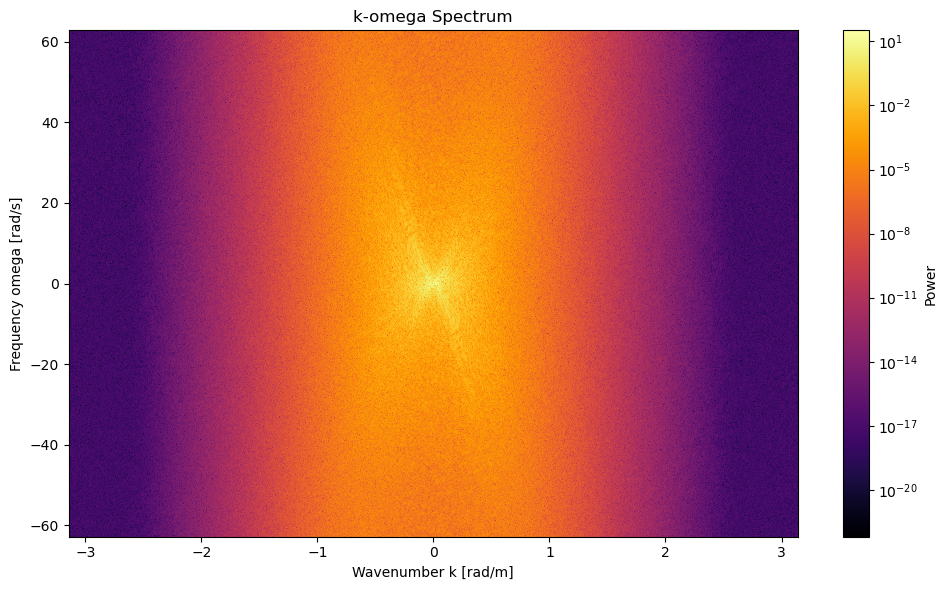

In [11]:
# Plot k-omega spectrum
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(k, omega, P.T, shading="auto", cmap="inferno", 
                   norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(im, ax=ax, label="Power")
ax.set_xlabel("Wavenumber k [rad/m]")
ax.set_ylabel("Frequency omega [rad/s]")
ax.set_title("k-omega Spectrum")
plt.tight_layout()

## k-omega Analysis

Apply k-omega spectral analysis to the real simulation data.  
Choose the spatial direction for the k-axis: `"x"` or `"y"`.

In [12]:
# ---- Configuration ----
FIELD = "Bz"            # Field component to analyze
K_DIRECTION = "x"       # "x" for k_x (average over y), "y" for k_y (average over x)
Y_SLICE = None           # If set, use a single index instead of averaging (e.g., ds.sizes["y"]//2)
X_SLICE = None           # Same for x when K_DIRECTION="y"

In [13]:
# Determine spatial spacing from coordinates
dx = float(ds.x[1] - ds.x[0])
dy = float(ds.y[1] - ds.y[0])
dt = ds.attrs.get("dt", float(ds.time[1] - ds.time[0]))

print(f"dx = {dx}, dy = {dy}, dt = {dt}")

# Extract the 2D slice (space, time) depending on chosen direction
da = ds[FIELD]

if K_DIRECTION == "x":
    d_space = dx
    if Y_SLICE is not None:
        slice_2d = da.isel(y=Y_SLICE).values  # shape: (time, x)
        print(f"Using single y-slice at index {Y_SLICE}")
    else:
        slice_2d = da.mean(dim="y").values     # shape: (time, x)
        print("Averaging over y")
    space_axis = 1  # x is axis 1 after (time, x)
    time_axis = 0
    k_label = "$k_x$"
elif K_DIRECTION == "y":
    d_space = dy
    if X_SLICE is not None:
        slice_2d = da.isel(x=X_SLICE).values  # shape: (time, y)
        print(f"Using single x-slice at index {X_SLICE}")
    else:
        slice_2d = da.mean(dim="x").values     # shape: (time, y)
        print("Averaging over x")
    space_axis = 1  # y is axis 1 after (time, y)
    time_axis = 0
    k_label = "$k_y$"
else:
    raise ValueError(f"K_DIRECTION must be 'x' or 'y', got '{K_DIRECTION}'")

print(f"2D slice shape: {slice_2d.shape} (time, {K_DIRECTION})")
print(f"d_space = {d_space}, dt = {dt}")

dx = 0.5, dy = 0.5, dt = 0.05


Averaging over y
2D slice shape: (1001, 1600) (time, x)
d_space = 0.5, dt = 0.05


In [14]:
# Compute k-omega spectrum
k, omega, P = compute_komega_2d(slice_2d, dx=d_space, dt=dt, axes=(space_axis, time_axis))

print(f"k range: [{k.min():.4f}, {k.max():.4f}] rad/d_i")
print(f"omega range: [{omega.min():.4f}, {omega.max():.4f}] rad/Omega_ci")

k range: [-6.2832, 6.2753] rad/d_i
omega range: [-62.7691, 62.7691] rad/Omega_ci


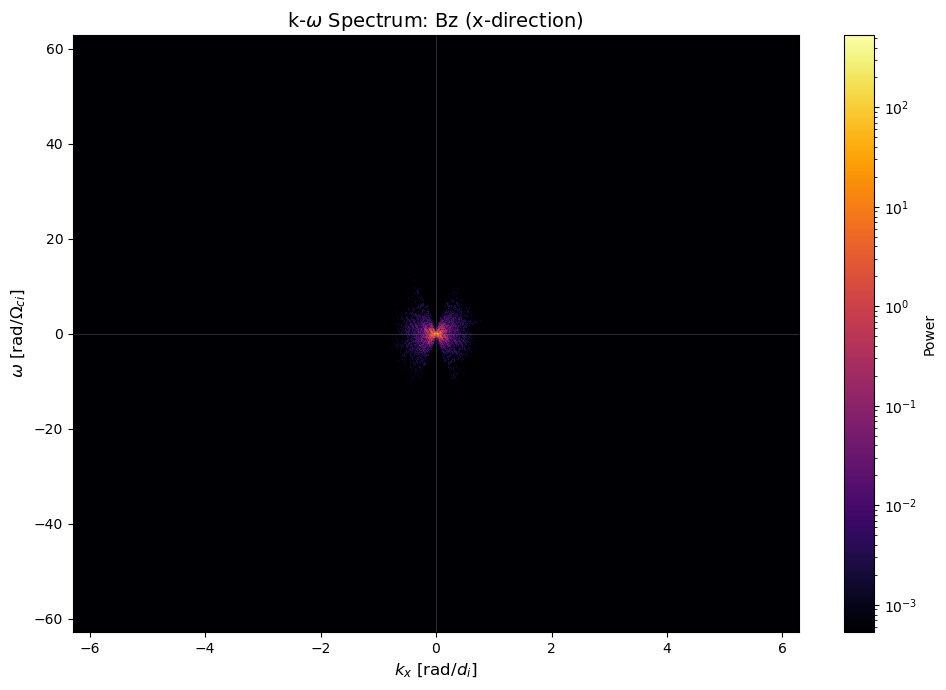

In [15]:
# Plot k-omega spectrum
fig, ax = plt.subplots(figsize=(10, 7))

im = ax.pcolormesh(k, omega, P.T, shading="auto", cmap="inferno",
                   norm=plt.matplotlib.colors.LogNorm(vmin=P.max() * 1e-6, vmax=P.max()))
plt.colorbar(im, ax=ax, label="Power")

ax.set_xlabel(f"{k_label} [rad/$d_i$]", fontsize=12)
ax.set_ylabel(r"$\omega$ [rad/$\Omega_{ci}$]", fontsize=12)
ax.set_title(f"k-$\\omega$ Spectrum: {FIELD} ({K_DIRECTION}-direction)", fontsize=14)
ax.axhline(0, color="gray", lw=0.5, alpha=0.5)
ax.axvline(0, color="gray", lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

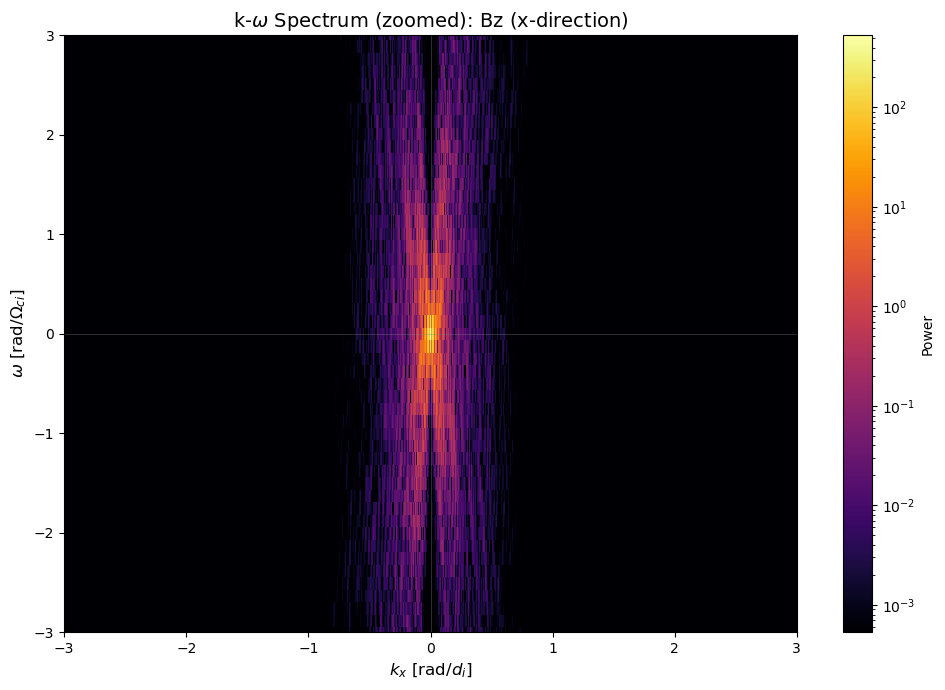

In [16]:
# Zoomed-in view — adjust limits as needed
K_MAX = 3.0    # rad/d_i
W_MAX = 3.0    # rad/Omega_ci

fig, ax = plt.subplots(figsize=(10, 7))

im = ax.pcolormesh(k, omega, P.T, shading="auto", cmap="inferno",
                   norm=plt.matplotlib.colors.LogNorm(vmin=P.max() * 1e-6, vmax=P.max()))
plt.colorbar(im, ax=ax, label="Power")

ax.set_xlabel(f"{k_label} [rad/$d_i$]", fontsize=12)
ax.set_ylabel(r"$\omega$ [rad/$\Omega_{ci}$]", fontsize=12)
ax.set_title(f"k-$\\omega$ Spectrum (zoomed): {FIELD} ({K_DIRECTION}-direction)", fontsize=14)
ax.set_xlim(-K_MAX, K_MAX)
ax.set_ylim(-W_MAX, W_MAX)
ax.axhline(0, color="gray", lw=0.5, alpha=0.5)
ax.axvline(0, color="gray", lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()